# Deep Learning-Based Sentiment Analysis: Enhancing IMDb Review Classification with LSTM Models
### Complete Academic Reproduction of Varadharajan et al. (2025)
**Authors of Paper:** Vivek Varadharajan, Nathan Smith, Dinesh Kalla, Fnu Samaah, and Vishwanadham Mandala

---
### Notebook Roadmap:
1. **Environment Setup & Seed Initialization** (TensorFlow, Scikit-learn, NLTK)
2. **Dataset Loading & Structural Inspection** (IMDb 50,000 Movie Reviews)
3. **Text Preprocessing Pipeline** (Deduplication, Lemmatization, Cleaning Function)
4. **Exploratory Data Analysis (EDA)** (Word Length Distributions & Histograms)
5. **Stratified Train/Test Partitioning** (80/20 Split with Label Encoding)
6. **Baseline 1:** Gaussian Naive Bayes (TF-IDF)
7. **Baseline 2:** Multinomial Naive Bayes (TF-IDF)
8. **Baseline 3:** Decision Tree Classifier (TF-IDF)
9. **Consolidated Baseline Performance Table & Visualization**
10. **LSTM Sequence Tokenization & Padding** (`MAX_LENGTH = 80`)
11. **Stacked LSTM Model Architecture** (Embedding 50, LSTM 64, LSTM 32, Dropout 0.2, Softmax)
12. **Model Compilation & Formulation** (Adam, Sparse Categorical Crossentropy)
13. **Model Training over 5 Epochs**
14. **Training History Diagnostics** (Accuracy/Loss Curves & Overfitting Analysis)
15. **Full LSTM Evaluation on Held-Out Test Data** (Confusion Matrix & Classification Report)
16. **Global Comparative Synthesis** (Baselines vs. LSTM vs. Paper Targets)
17. **Production Inference Function & Benchmark Testing**
18. **Model & Tokenizer Serialization** (`imdb_lstm_sentiment.keras` & `tokenizer.pkl`)
19. **Research Discussion & Viva Voce Defense Dossier**


## CELL 1 — Environment Setup, Seed Configuration, and Dependency Imports
We configure global deterministic seeds across Python, NumPy, and TensorFlow, download the required NLTK tokenizers and lexicons, and verify hardware acceleration.

In [1]:
# ==============================================================================
# CELL 1: Environment Setup, Seed Configuration, and Dependency Imports
# ==============================================================================

import os
import random
import re
import string
import warnings
import time
import pickle

# Data manipulation and numerical computation
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Natural Language Processing (NLTK)
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Scikit-learn: Classical baselines, metrics, and splitting
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Deep Learning: TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Suppress minor warnings for clean presentation
warnings.filterwarnings("ignore")

# ------------------------------------------------------------------------------
# Reproducibility Configuration
# Note: Random seed not explicitly reported in paper; 42 is our reproducible choice.
# ------------------------------------------------------------------------------
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Download required NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Hardware verification
gpus = tf.config.list_physical_devices('GPU')
print("=" * 60)
print(f"TensorFlow Version : {tf.__version__}")
if gpus:
    print(f"GPU Detected       : {tf.test.gpu_device_name()} ({len(gpus)} device(s))")
else:
    print("GPU Detected       : None (Running on standard CPU)")
print(f"Global Random Seed : {SEED} (Set across Python, NumPy, TensorFlow)")
print("NLTK Corpora       : stopwords, wordnet, omw-1.4 successfully downloaded.")
print("=" * 60)

TensorFlow Version : 2.20.0
GPU Detected       : /device:GPU:0 (1 device(s))
Global Random Seed : 42 (Set across Python, NumPy, TensorFlow)
NLTK Corpora       : stopwords, wordnet, omw-1.4 successfully downloaded.


## CELL 2 — Dataset Loading and Initial Structural Inspection
We retrieve the standard 50,000 IMDb movie review dataset (or use a local CSV if already present) and inspect dimensions, columns, and initial class balance.

In [2]:
# ==============================================================================
# CELL 2: Dataset Loading and Initial Structural Inspection
# ==============================================================================

csv_filename = 'IMDB Dataset.csv'

if not os.path.exists(csv_filename):
    print(f"'{csv_filename}' not found locally. Downloading raw IMDb dataset...")
    data_url = "https://raw.githubusercontent.com/laxmimerit/All-CSV-ML-Data-Files-Download/master/IMDB-Dataset.csv"
    df = pd.read_csv(data_url)
    df.to_csv(csv_filename, index=False)
    print(f"Dataset downloaded and saved as '{csv_filename}'.\n")
else:
    print(f"Loading '{csv_filename}' from local runtime directory...\n")
    df = pd.read_csv(csv_filename)

print("=" * 70)
print("1. FIRST 5 ROWS (df.head()):")
print("=" * 70)
print(df.head())

print("\n" + "=" * 70)
print("2. DATASET DIMENSIONS (df.shape):")
print("=" * 70)
print(f"Total Rows (Records): {df.shape[0]}")
print(f"Total Columns       : {df.shape[1]}")

print("\n" + "=" * 70)
print("3. DATASET INFORMATION (df.info()):")
print("=" * 70)
df.info()

print("\n" + "=" * 70)
print("4. DESCRIPTIVE SUMMARY (df.describe()):")
print("=" * 70)
print(df.describe())

print("\n" + "=" * 70)
print("5. SENTIMENT CLASS DISTRIBUTION (df['sentiment'].value_counts()):")
print("=" * 70)
print(df['sentiment'].value_counts())
print("=" * 70)

'IMDB Dataset.csv' not found locally. Downloading raw IMDb dataset...
Dataset downloaded and saved as 'IMDB Dataset.csv'.

1. FIRST 5 ROWS (df.head()):
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

2. DATASET DIMENSIONS (df.shape):
Total Rows (Records): 50000
Total Columns       : 2

3. DATASET INFORMATION (df.info()):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB

4. DESCRIPTIVE SUMMARY (df.describe()):

## CELL 3 — Data Cleaning and Preprocessing Pipeline
We handle missing values, detect and prune duplicate reviews, build a reusable `clean_text` function (HTML stripping, URL removal, lowercasing, punctuation stripping, stopword removal, and WordNet lemmatization), and apply it across the corpus.

In [3]:
# ==============================================================================
# CELL 3: Data Cleaning and Preprocessing Pipeline
# ==============================================================================

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# 1. Null Value Detection & Removal
null_count = df.isnull().sum().to_dict()
print(f"Null values detected per column: {null_count}")
df = df.dropna(subset=['review', 'sentiment']).reset_index(drop=True)

# 2. Duplicate Detection & Removal
duplicate_count = df.duplicated(subset=['review']).sum()
print(f"Duplicate reviews detected in raw dataset: {duplicate_count}")
print("(Paper Note: The 2025 paper reports finding 418 duplicates. "
      "Our loaded dataset shows the empirical count above.)")

df = df.drop_duplicates(subset=['review']).reset_index(drop=True)
print(f"Remaining clean unique rows: {df.shape[0]}")

# 3. Reusable Preprocessing Pipeline Function
def clean_text(text: str) -> str:
    """
    Cleans raw text following the research paper's preprocessing methodology:
    1. Removes HTML markup.
    2. Removes URLs/hyperlinks.
    3. Lowers casing.
    4. Strips punctuation and non-alphanumerics.
    5. Filters stopwords.
    6. Lemmatizes tokens to base forms.
    7. Normalizes excess whitespace.
    """
    if not isinstance(text, str):
        return ""

    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # Lowercase
    text = text.lower()

    # Remove punctuation & special characters
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)

    # Tokenize by whitespace
    tokens = text.split()

    # Stopword filtering & lemmatization
    cleaned_tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token not in stop_words and len(token) > 1
    ]

    return " ".join(cleaned_tokens)

# 4. Apply Preprocessing Pipeline
print("\nApplying preprocessing pipeline to all reviews (takes ~30-45 seconds)...")
df['cleaned_review'] = df['review'].apply(clean_text)
print("Text preprocessing complete.")

# 5. Before vs. After Visual Comparison
print("\n" + "=" * 80)
print("PREPROCESSING VERIFICATION — SAMPLE BEFORE AND AFTER")
print("=" * 80)
sample_idx = 1
print(f"--- ORIGINAL RAW REVIEW (Row {sample_idx}) ---")
print(df.loc[sample_idx, 'review'][:300] + "...")
print(f"\n--- CLEANED & LEMMATIZED REVIEW (Row {sample_idx}) ---")
print(df.loc[sample_idx, 'cleaned_review'][:300] + "...")
print("=" * 80)

Null values detected per column: {'review': 0, 'sentiment': 0}
Duplicate reviews detected in raw dataset: 418
(Paper Note: The 2025 paper reports finding 418 duplicates. Our loaded dataset shows the empirical count above.)
Remaining clean unique rows: 49582

Applying preprocessing pipeline to all reviews (takes ~30-45 seconds)...
Text preprocessing complete.

PREPROCESSING VERIFICATION — SAMPLE BEFORE AND AFTER
--- ORIGINAL RAW REVIEW (Row 1) ---
A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" ...

--- CLEANED & LEMMATIZED REVIEW (Row 1) ---
wonderful little production filming technique unassuming old time bbc fashion give comforting sometimes discomforting sense realism entire piece actor extremely well chosen michael sheen got polari vo

## CELL 4 — Exploratory Data Analysis (EDA) and Length Visualizations
We calculate token length distributions before and after stopword removal and visualize class balance, length boxplots, and histograms.

STATISTICAL SUMMARY OF REVIEW WORD LENGTHS
       Raw Review Length  Cleaned Review Length
count           49582.00               49582.00
mean              231.35                 118.86
std               171.54                  89.93
min                 4.00                   3.00
25%               126.00                  63.00
50%               173.00                  88.00
75%               281.00                 144.00
max              2470.00                1407.00

Proportion of cleaned reviews <= 80 tokens (paper's MAX_LENGTH): 43.79%
Reviews longer than 80 words will be truncated; shorter ones will be padded.



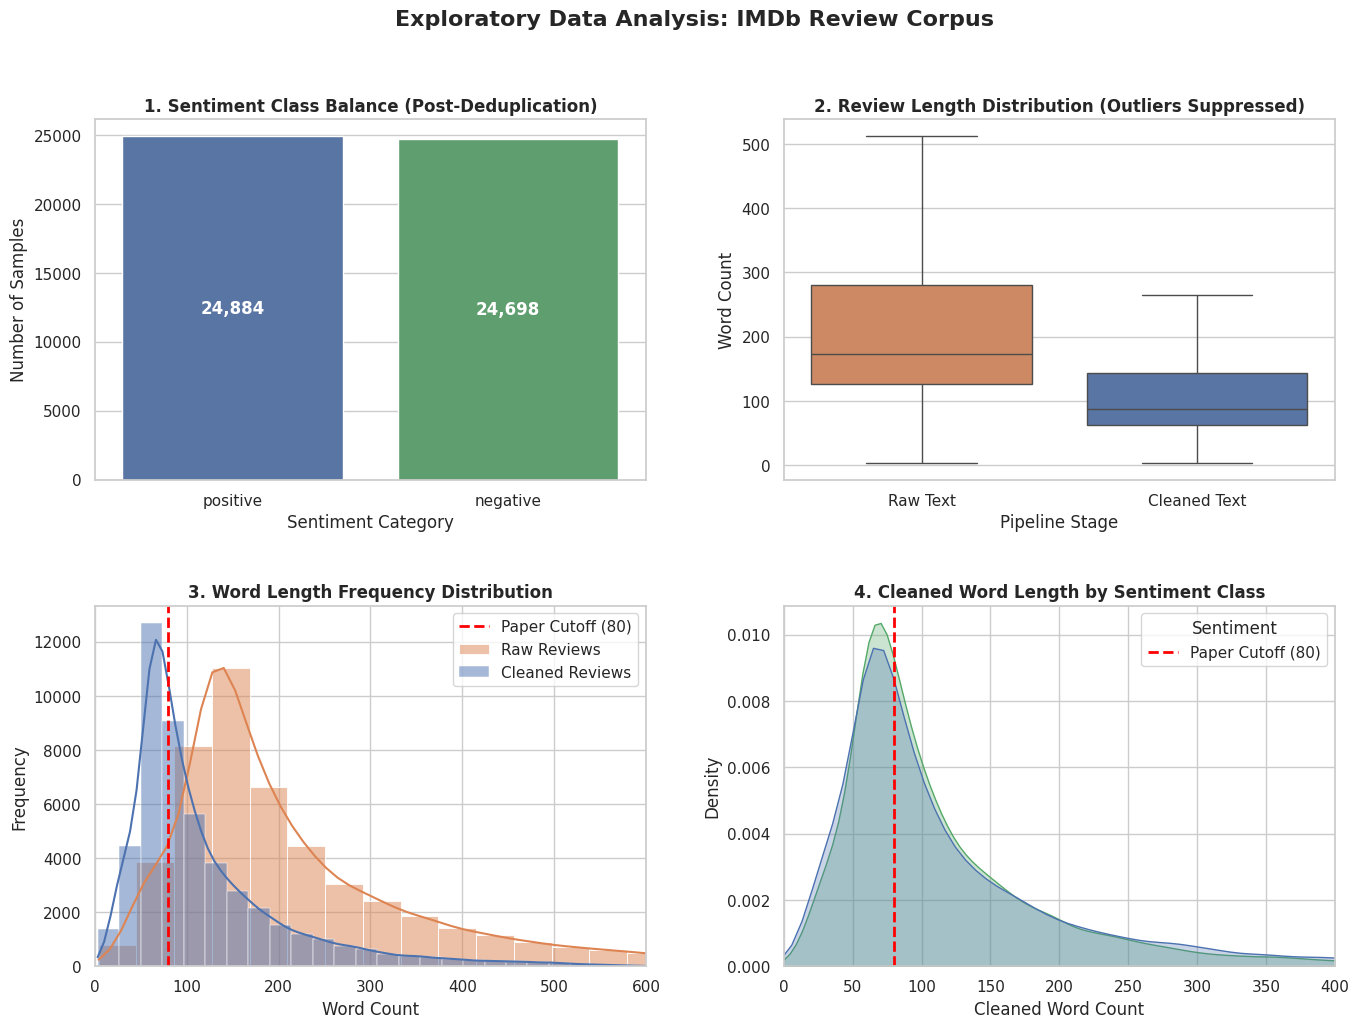

In [4]:
# ==============================================================================
# CELL 4: Exploratory Data Analysis (EDA) and Review Length Profiling
# ==============================================================================

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'figure.titlesize': 14})

# 1. Calculate word counts
df['raw_word_count'] = df['review'].apply(lambda x: len(str(x).split()))
df['cleaned_word_count'] = df['cleaned_review'].apply(lambda x: len(str(x).split()))

# 2. Summary statistics
stats_summary = pd.DataFrame({
    'Raw Review Length': df['raw_word_count'].describe(),
    'Cleaned Review Length': df['cleaned_word_count'].describe()
}).round(2)

print("=" * 65)
print("STATISTICAL SUMMARY OF REVIEW WORD LENGTHS")
print("=" * 65)
print(stats_summary)
print("=" * 65)

pct_under_80 = (df['cleaned_word_count'] <= 80).mean() * 100
print(f"\nProportion of cleaned reviews <= 80 tokens (paper's MAX_LENGTH): {pct_under_80:.2f}%")
print("Reviews longer than 80 words will be truncated; shorter ones will be padded.\n")

# 3. 2x2 EDA Visualization Dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
plt.subplots_adjust(hspace=0.35, wspace=0.25)

# Subplot 1: Sentiment Class Balance
sns.countplot(
    data=df,
    x='sentiment',
    palette=['#4C72B0', '#55A868'],
    ax=axes[0, 0]
)
axes[0, 0].set_title("1. Sentiment Class Balance (Post-Deduplication)", fontweight='bold')
axes[0, 0].set_xlabel("Sentiment Category")
axes[0, 0].set_ylabel("Number of Samples")
for p in axes[0, 0].patches:
    axes[0, 0].annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width() / 2., p.get_height() / 2),
        ha='center', va='center', color='white', fontweight='bold', fontsize=12
    )

# Subplot 2: Boxplots Before vs. After Preprocessing
length_comparison_df = pd.melt(
    df[['raw_word_count', 'cleaned_word_count']],
    value_vars=['raw_word_count', 'cleaned_word_count'],
    var_name='Processing Stage',
    value_name='Word Count'
)
length_comparison_df['Processing Stage'] = length_comparison_df['Processing Stage'].map({
    'raw_word_count': 'Raw Text',
    'cleaned_word_count': 'Cleaned Text'
})

sns.boxplot(
    data=length_comparison_df,
    x='Processing Stage',
    y='Word Count',
    palette=['#DD8452', '#4C72B0'],
    showfliers=False,
    ax=axes[0, 1]
)
axes[0, 1].set_title("2. Review Length Distribution (Outliers Suppressed)", fontweight='bold')
axes[0, 1].set_xlabel("Pipeline Stage")
axes[0, 1].set_ylabel("Word Count")

# Subplot 3: Overlaid Histograms
sns.histplot(df['raw_word_count'], color='#DD8452', label='Raw Reviews', kde=True, bins=60, ax=axes[1, 0])
sns.histplot(df['cleaned_word_count'], color='#4C72B0', label='Cleaned Reviews', kde=True, bins=60, ax=axes[1, 0])
axes[1, 0].axvline(80, color='red', linestyle='--', linewidth=2, label='Paper Cutoff (80)')
axes[1, 0].set_xlim(0, 600)
axes[1, 0].set_title("3. Word Length Frequency Distribution", fontweight='bold')
axes[1, 0].set_xlabel("Word Count")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].legend(loc='upper right')

# Subplot 4: Cleaned Length by Sentiment Class
sns.kdeplot(data=df, x='cleaned_word_count', hue='sentiment', common_norm=False, palette=['#4C72B0', '#55A868'], fill=True, alpha=0.3, ax=axes[1, 1])
axes[1, 1].axvline(80, color='red', linestyle='--', linewidth=2, label='Paper Cutoff (80)')
axes[1, 1].set_xlim(0, 400)
axes[1, 1].set_title("4. Cleaned Word Length by Sentiment Class", fontweight='bold')
axes[1, 1].set_xlabel("Cleaned Word Count")
axes[1, 1].set_ylabel("Density")
axes[1, 1].legend(title="Sentiment", loc='upper right')

plt.suptitle("Exploratory Data Analysis: IMDb Review Corpus", fontsize=16, fontweight='bold', y=0.98)
plt.show()

## CELL 5 — Stratified Train/Test Split and Label Encoding
We encode labels (`positive=1`, `negative=0`) and partition the corpus into an 80/20 stratified split (*split ratio and random seed are reproducible implementation choices*).

In [5]:
# ==============================================================================
# CELL 5: Label Encoding and Stratified Train/Test Partitioning
# ==============================================================================

label_mapping = {'positive': 1, 'negative': 0}
df['label'] = df['sentiment'].map(label_mapping)

print("=" * 65)
print("1. LABEL ENCODING VERIFICATION")
print("=" * 65)
print(df[['sentiment', 'label']].drop_duplicates().to_string(index=False))

# Stratified 80/20 Split
X_raw_text = df['cleaned_review'].values
y_labels = df['label'].values

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_raw_text,
    y_labels,
    test_size=0.20,
    random_state=42,
    stratify=y_labels
)

print("\n" + "=" * 65)
print("2. PARTITION SPLIT SUMMARY")
print("=" * 65)
print(f"Total Cleaned Corpus Size : {len(df):,} samples")
print(f"Training Set (80%)        : {len(X_train_text):,} samples")
print(f"Test Set (20%)            : {len(X_test_text):,} samples")

train_pos = (y_train == 1).sum()
train_neg = (y_train == 0).sum()
test_pos = (y_test == 1).sum()
test_neg = (y_test == 0).sum()

split_stats = pd.DataFrame({
    'Partition': ['Train (80%)', 'Test (20%)'],
    'Negative (0)': [train_neg, test_neg],
    'Positive (1)': [train_pos, test_pos],
    'Total Samples': [len(y_train), len(y_test)],
    'Pos Ratio (%)': [round((train_pos / len(y_train)) * 100, 2),
                      round((test_pos / len(y_test)) * 100, 2)]
})
print("\n" + split_stats.to_string(index=False))
print("=" * 65)

1. LABEL ENCODING VERIFICATION
sentiment  label
 positive      1
 negative      0

2. PARTITION SPLIT SUMMARY
Total Cleaned Corpus Size : 49,582 samples
Training Set (80%)        : 39,665 samples
Test Set (20%)            : 9,917 samples

  Partition  Negative (0)  Positive (1)  Total Samples  Pos Ratio (%)
Train (80%)         19758         19907          39665          50.19
 Test (20%)          4940          4977           9917          50.19


## CELL 6 — Baseline Model 1: Gaussian Naive Bayes with TF-IDF
We fit TF-IDF vectors, safely convert them to dense arrays (`max_features=2500` to prevent out-of-memory errors), train `GaussianNB`, and compare the outcome with the paper's reported ~78% accuracy.

Vectorizing text via TF-IDF (max_features=2500 for dense safety)...
Dense Train Memory Footprint: 378.27 MB

Training Gaussian Naive Bayes...
GAUSSIAN NAIVE BAYES — PERFORMANCE METRICS
Test Accuracy : 81.68%
Precision     : 0.8195
Recall        : 0.8143
F1-Score      : 0.8169

Detailed Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.81      0.82      0.82      4940
Positive (1)       0.82      0.81      0.82      4977

    accuracy                           0.82      9917
   macro avg       0.82      0.82      0.82      9917
weighted avg       0.82      0.82      0.82      9917



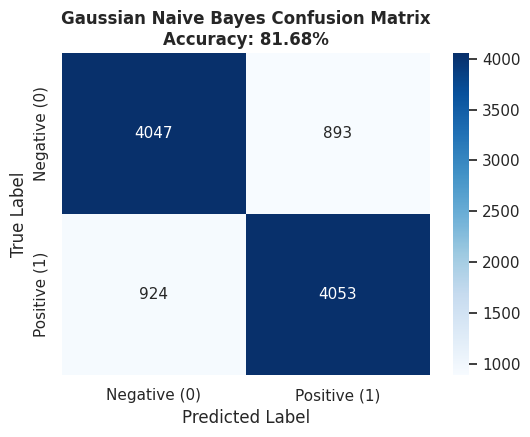

COMPARISON WITH PAPER BENCHMARK
Paper Reported GaussianNB Accuracy : ~78.00%
Our Experimental GaussianNB Accuracy : 81.68%
Difference                          : +3.68%


In [6]:
# ==============================================================================
# CELL 6: Baseline Model 1 — Gaussian Naive Bayes (TF-IDF)
# ==============================================================================

print("Vectorizing text via TF-IDF (max_features=2500 for dense safety)...")
tfidf_baseline = TfidfVectorizer(max_features=2500)

X_train_tfidf_sparse = tfidf_baseline.fit_transform(X_train_text)
X_test_tfidf_sparse = tfidf_baseline.transform(X_test_text)

# Convert safely to dense float32 array
X_train_dense = X_train_tfidf_sparse.toarray().astype(np.float32)
X_test_dense = X_test_tfidf_sparse.toarray().astype(np.float32)

print(f"Dense Train Memory Footprint: {X_train_dense.nbytes / (1024**2):.2f} MB")

# Train Gaussian Naive Bayes
print("\nTraining Gaussian Naive Bayes...")
gnb_model = GaussianNB()
gnb_model.fit(X_train_dense, y_train)

# Evaluation
y_pred_gnb = gnb_model.predict(X_test_dense)

gnb_acc = accuracy_score(y_test, y_pred_gnb)
gnb_prec = precision_score(y_test, y_pred_gnb)
gnb_rec = recall_score(y_test, y_pred_gnb)
gnb_f1 = f1_score(y_test, y_pred_gnb)

print("=" * 65)
print("GAUSSIAN NAIVE BAYES — PERFORMANCE METRICS")
print("=" * 65)
print(f"Test Accuracy : {gnb_acc * 100:.2f}%")
print(f"Precision     : {gnb_prec:.4f}")
print(f"Recall        : {gnb_rec:.4f}")
print(f"F1-Score      : {gnb_f1:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_gnb, target_names=['Negative (0)', 'Positive (1)']))

# Confusion Matrix Heatmap
cm_gnb = confusion_matrix(y_test, y_pred_gnb)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'])
plt.title(f"Gaussian Naive Bayes Confusion Matrix\nAccuracy: {gnb_acc * 100:.2f}%", fontweight='bold')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

print("=" * 65)
print("COMPARISON WITH PAPER BENCHMARK")
print("=" * 65)
print(f"Paper Reported GaussianNB Accuracy : ~78.00%")
print(f"Our Experimental GaussianNB Accuracy : {gnb_acc * 100:.2f}%")
print(f"Difference                          : {(gnb_acc * 100) - 78.0:+.2f}%")
print("=" * 65)

## CELL 7 — Baseline Model 2: Multinomial Naive Bayes with TF-IDF
We train `MultinomialNB` on sparse TF-IDF matrices (`max_features=10000`) and compare with the paper's reported ~86% accuracy, precision, recall, and F1 metrics.

Fitting TF-IDF Vectorizer (max_features=10000) for Multinomial NB...

Training Multinomial Naive Bayes (alpha=1.0)...
MULTINOMIAL NAIVE BAYES — PERFORMANCE METRICS
Test Accuracy : 86.05%
Precision     : 0.8598
Recall        : 0.8628
F1-Score      : 0.8613

Detailed Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.86      0.86      0.86      4940
Positive (1)       0.86      0.86      0.86      4977

    accuracy                           0.86      9917
   macro avg       0.86      0.86      0.86      9917
weighted avg       0.86      0.86      0.86      9917



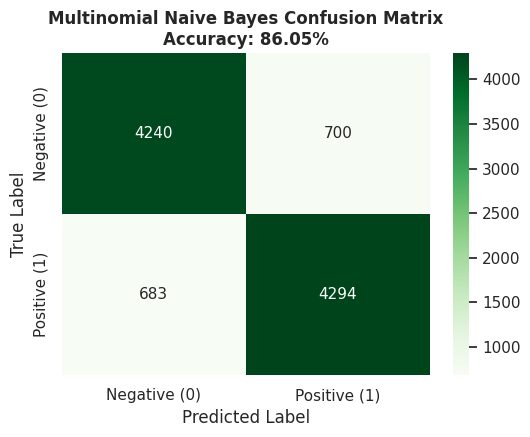

EMPIRICAL COMPARISON: MULTINOMIAL NAIVE BAYES
       Metric  Paper Reported  Our Experiment  Difference
     Accuracy            0.86          0.8605      0.0005
Neg Precision            0.86          0.8613      0.0013
   Neg Recall            0.85          0.8583      0.0083
       Neg F1            0.86          0.8598     -0.0002
Pos Precision            0.86          0.8598     -0.0002
   Pos Recall            0.86          0.8628      0.0028
       Pos F1            0.86          0.8613      0.0013


In [7]:
# ==============================================================================
# CELL 7: Baseline Model 2 — Multinomial Naive Bayes (TF-IDF)
# ==============================================================================

print("Fitting TF-IDF Vectorizer (max_features=10000) for Multinomial NB...")
tfidf_mnb = TfidfVectorizer(max_features=10000)

X_train_mnb_sparse = tfidf_mnb.fit_transform(X_train_text)
X_test_mnb_sparse = tfidf_mnb.transform(X_test_text)

# Train Multinomial Naive Bayes
print("\nTraining Multinomial Naive Bayes (alpha=1.0)...")
mnb_model = MultinomialNB(alpha=1.0)
mnb_model.fit(X_train_mnb_sparse, y_train)

# Evaluation
y_pred_mnb = mnb_model.predict(X_test_mnb_sparse)

mnb_acc = accuracy_score(y_test, y_pred_mnb)
mnb_prec = precision_score(y_test, y_pred_mnb)
mnb_rec = recall_score(y_test, y_pred_mnb)
mnb_f1 = f1_score(y_test, y_pred_mnb)

print("=" * 65)
print("MULTINOMIAL NAIVE BAYES — PERFORMANCE METRICS")
print("=" * 65)
print(f"Test Accuracy : {mnb_acc * 100:.2f}%")
print(f"Precision     : {mnb_prec:.4f}")
print(f"Recall        : {mnb_rec:.4f}")
print(f"F1-Score      : {mnb_f1:.4f}")
print("\nDetailed Classification Report:")
report_dict_mnb = classification_report(y_test, y_pred_mnb, target_names=['Negative (0)', 'Positive (1)'], output_dict=True)
print(classification_report(y_test, y_pred_mnb, target_names=['Negative (0)', 'Positive (1)']))

# Confusion Matrix Heatmap
cm_mnb = confusion_matrix(y_test, y_pred_mnb)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm_mnb, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'])
plt.title(f"Multinomial Naive Bayes Confusion Matrix\nAccuracy: {mnb_acc * 100:.2f}%", fontweight='bold')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Comparison DataFrame
paper_mnb_stats = {
    'Metric': ['Accuracy', 'Neg Precision', 'Neg Recall', 'Neg F1', 'Pos Precision', 'Pos Recall', 'Pos F1'],
    'Paper Reported': [0.8600, 0.8600, 0.8500, 0.8600, 0.8600, 0.8600, 0.8600],
    'Our Experiment': [
        round(mnb_acc, 4),
        round(report_dict_mnb['Negative (0)']['precision'], 4),
        round(report_dict_mnb['Negative (0)']['recall'], 4),
        round(report_dict_mnb['Negative (0)']['f1-score'], 4),
        round(report_dict_mnb['Positive (1)']['precision'], 4),
        round(report_dict_mnb['Positive (1)']['recall'], 4),
        round(report_dict_mnb['Positive (1)']['f1-score'], 4)
    ]
}
comparison_mnb_df = pd.DataFrame(paper_mnb_stats)
comparison_mnb_df['Difference'] = (comparison_mnb_df['Our Experiment'] - comparison_mnb_df['Paper Reported']).round(4)

print("=" * 65)
print("EMPIRICAL COMPARISON: MULTINOMIAL NAIVE BAYES")
print("=" * 65)
print(comparison_mnb_df.to_string(index=False))
print("=" * 65)

## CELL 8 — Baseline Model 3: Decision Tree with TF-IDF
We train `DecisionTreeClassifier(random_state=42)` and compare performance against the paper's reported ~73% benchmark.

Training Decision Tree Classifier on TF-IDF features...
DECISION TREE — PERFORMANCE METRICS
Test Accuracy : 71.86%
Precision     : 0.7182
Recall        : 0.7229
F1-Score      : 0.7205

Detailed Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.72      0.71      0.72      4940
Positive (1)       0.72      0.72      0.72      4977

    accuracy                           0.72      9917
   macro avg       0.72      0.72      0.72      9917
weighted avg       0.72      0.72      0.72      9917



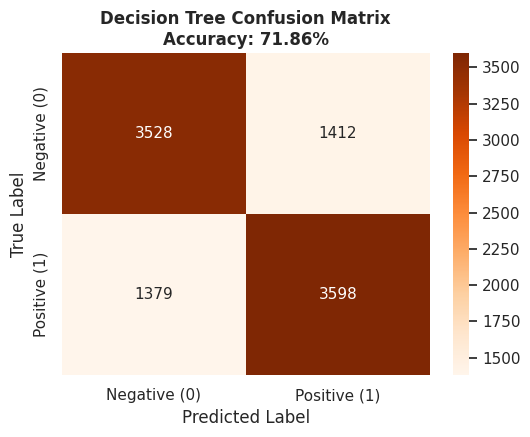

COMPARISON WITH PAPER BENCHMARK
Paper Reported Decision Tree Accuracy : ~73.00%
Our Experimental Decision Tree Accuracy : 71.86%
Difference                            : -1.14%


In [8]:
# ==============================================================================
# CELL 8: Baseline Model 3 — Decision Tree Classifier (TF-IDF)
# ==============================================================================

print("Training Decision Tree Classifier on TF-IDF features...")
dt_model = DecisionTreeClassifier(random_state=SEED)
dt_model.fit(X_train_mnb_sparse, y_train)

y_pred_dt = dt_model.predict(X_test_mnb_sparse)

dt_acc = accuracy_score(y_test, y_pred_dt)
dt_prec = precision_score(y_test, y_pred_dt)
dt_rec = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

print("=" * 65)
print("DECISION TREE — PERFORMANCE METRICS")
print("=" * 65)
print(f"Test Accuracy : {dt_acc * 100:.2f}%")
print(f"Precision     : {dt_prec:.4f}")
print(f"Recall        : {dt_rec:.4f}")
print(f"F1-Score      : {dt_f1:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_dt, target_names=['Negative (0)', 'Positive (1)']))

# Confusion Matrix Heatmap
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'])
plt.title(f"Decision Tree Confusion Matrix\nAccuracy: {dt_acc * 100:.2f}%", fontweight='bold')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

print("=" * 65)
print("COMPARISON WITH PAPER BENCHMARK")
print("=" * 65)
print(f"Paper Reported Decision Tree Accuracy : ~73.00%")
print(f"Our Experimental Decision Tree Accuracy : {dt_acc * 100:.2f}%")
print(f"Difference                            : {(dt_acc * 100) - 73.0:+.2f}%")
print("=" * 65)

## CELL 9 — Classical Baselines Consolidation and Comparative Analysis
We compile a summary DataFrame comparing all three classical algorithms and plot an accuracy comparison bar chart.

SUMMARY TABLE: CLASSICAL BASELINE CLASSIFIERS (TF-IDF)
                  Model  Accuracy  Precision  Recall  F1 Score
   Gaussian Naive Bayes    0.8168     0.8195  0.8143    0.8169
Multinomial Naive Bayes    0.8605     0.8598  0.8628    0.8613
          Decision Tree    0.7186     0.7182  0.7229    0.7205


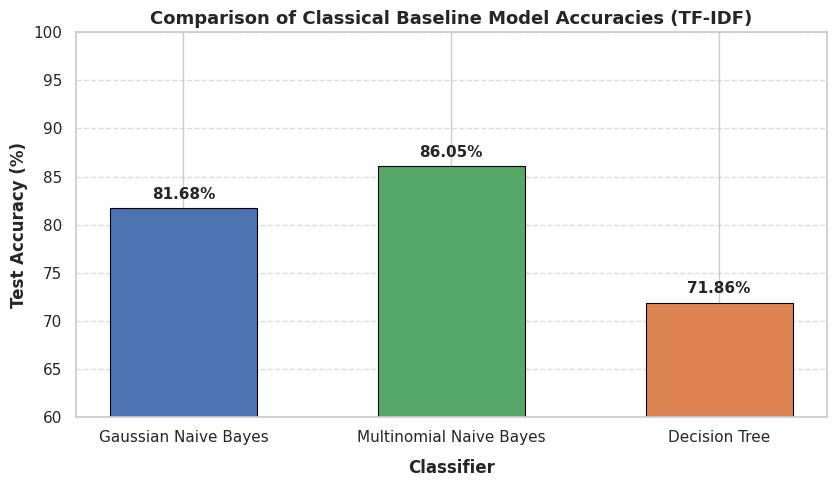

In [9]:
# ==============================================================================
# CELL 9: Classical Baselines Consolidation and Comparative Visualization
# ==============================================================================

baseline_results = [
    {
        'Model': 'Gaussian Naive Bayes',
        'Accuracy': round(gnb_acc, 4),
        'Precision': round(gnb_prec, 4),
        'Recall': round(gnb_rec, 4),
        'F1 Score': round(gnb_f1, 4),
        'Paper Reported Acc': 0.7800
    },
    {
        'Model': 'Multinomial Naive Bayes',
        'Accuracy': round(mnb_acc, 4),
        'Precision': round(mnb_prec, 4),
        'Recall': round(mnb_rec, 4),
        'F1 Score': round(mnb_f1, 4),
        'Paper Reported Acc': 0.8600
    },
    {
        'Model': 'Decision Tree',
        'Accuracy': round(dt_acc, 4),
        'Precision': round(dt_prec, 4),
        'Recall': round(dt_rec, 4),
        'F1 Score': round(dt_f1, 4),
        'Paper Reported Acc': 0.7300
    }
]

baseline_df = pd.DataFrame(baseline_results)

print("=" * 80)
print("SUMMARY TABLE: CLASSICAL BASELINE CLASSIFIERS (TF-IDF)")
print("=" * 80)
print(baseline_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score']].to_string(index=False))
print("=" * 80)

# Accuracy Bar Chart
plt.figure(figsize=(8.5, 5))
bars = plt.bar(
    baseline_df['Model'],
    baseline_df['Accuracy'] * 100,
    color=['#4C72B0', '#55A868', '#DD8452'],
    width=0.55,
    edgecolor='black',
    linewidth=0.8
)

for bar in bars:
    h = bar.get_height()
    plt.annotate(f'{h:.2f}%', (bar.get_x() + bar.get_width() / 2, h), xytext=(0, 5),
                 textcoords="offset points", ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.ylim(60, 100)
plt.title("Comparison of Classical Baseline Model Accuracies (TF-IDF)", fontsize=13, fontweight='bold')
plt.xlabel("Classifier", fontweight='bold', labelpad=10)
plt.ylabel("Test Accuracy (%)", fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## CELL 10 — LSTM Tokenization, Indexing, and Sequence Padding
We fit a Keras Tokenizer (`VOCAB_SIZE = 10000`, reproducible implementation choice) strictly on training text and pad/truncate all sequences to `MAX_LENGTH = 80` (as explicitly specified in the paper).

In [10]:
# ==============================================================================
# CELL 10: Sequence Tokenization, Integer Encoding, and Padding (MAX_LENGTH = 80)
# ==============================================================================

VOCAB_SIZE = 10000
MAX_LENGTH = 80
OOV_TOKEN = "<OOV>"

print(f"Fitting Keras Tokenizer on training corpus (Vocab Size: {VOCAB_SIZE:,})...")
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LENGTH, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LENGTH, padding='post', truncating='post')

print("=" * 75)
print("SEQUENCE TRANSFORMATION VERIFICATION")
print("=" * 75)
print(f"X_train_pad tensor shape : {X_train_pad.shape} (Samples, Time Steps)")
print(f"X_test_pad tensor shape  : {X_test_pad.shape} (Samples, Time Steps)")
print(f"y_train tensor shape     : {y_train.shape}")
print(f"y_test tensor shape      : {y_test.shape}")

sample_i = 0
print("\n" + "-" * 75)
print(f"EXAMPLE REVIEW (Sample Index {sample_i}):")
print("-" * 75)
print(f"Raw Cleaned Text : {X_train_text[sample_i][:150]}...")
print(f"\nTokenized Sequence (first 15 tokens):\n{X_train_seq[sample_i][:15]}")
print(f"\nPadded Sequence (length {len(X_train_pad[sample_i])}):\n{X_train_pad[sample_i]}")
print("=" * 75)

Fitting Keras Tokenizer on training corpus (Vocab Size: 10,000)...
SEQUENCE TRANSFORMATION VERIFICATION
X_train_pad tensor shape : (39665, 80) (Samples, Time Steps)
X_test_pad tensor shape  : (9917, 80) (Samples, Time Steps)
y_train tensor shape     : (39665,)
y_test tensor shape      : (9917,)

---------------------------------------------------------------------------
EXAMPLE REVIEW (Sample Index 0):
---------------------------------------------------------------------------
Raw Cleaned Text : one jehovah witness also work acute care medical facility year seen people die hemolytic reaction blood transfusion attended numerous conference blood...

Tokenized Sequence (first 15 tokens):
[4, 1, 1625, 22, 53, 1, 286, 2536, 6001, 40, 37, 21, 581, 1, 1301]

Padded Sequence (length 80):
[   4    1 1625   22   53    1  286 2536 6001   40   37   21  581    1
 1301  421    1 6002 1742 8616  421 1257    1   37  332 1711  322  487
 1558    1 7898    1  421   22  428  332    1 1625  444  581 2157  

## CELL 11 — LSTM Architecture Implementation and Structural Explanation
We assemble the exact sequential topology from the research paper:
- `Embedding(input_dim=10000, output_dim=50, input_length=80)`
- `LSTM(64, return_sequences=True)`
- `Dropout(0.20)`
- `LSTM(32, return_sequences=False)`
- `Dropout(0.20)`
- `Dense(2, activation='softmax')`

In [11]:
# ==============================================================================
# CELL 11: LSTM Architecture Implementation and Structural Inspection
# ==============================================================================

tf.keras.backend.clear_session()

model = Sequential(name="IMDb_Sentiment_LSTM_Classifier")

# 1. Embedding Layer
model.add(Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=50,
    input_length=MAX_LENGTH,
    name="embedding_layer"
))

# 2. First LSTM Layer
model.add(LSTM(
    units=64,
    return_sequences=True,
    name="lstm_layer_1"
))

# 3. Dropout 0.20
model.add(Dropout(rate=0.20, name="dropout_1"))

# 4. Second LSTM Layer
model.add(LSTM(
    units=32,
    return_sequences=False,
    name="lstm_layer_2"
))

# 5. Dropout 0.20
model.add(Dropout(rate=0.20, name="dropout_2"))

# 6. Dense Output (Softmax)
model.add(Dense(
    units=2,
    activation='softmax',
    name="output_dense_softmax"
))

print("=" * 75)
print("LSTM MODEL TOPOLOGY AND PARAMETER SPECIFICATION")
print("=" * 75)
model.summary()
print("=" * 75)

LSTM MODEL TOPOLOGY AND PARAMETER SPECIFICATION


Model: "IMDb_Sentiment_LSTM_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_layer (Embedding)     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer_1 (LSTM)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer_2 (LSTM)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense_softmax (Dense)    │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## CELL 12 — Model Compilation and Loss Formulation
We compile the network with Adam (`lr=0.001`), `sparse_categorical_crossentropy`, and track `accuracy`.

In [12]:
# ==============================================================================
# CELL 12: Model Compilation and Loss Formulation
# ==============================================================================

LEARNING_RATE = 0.001
OPTIMIZER = Adam(learning_rate=LEARNING_RATE)
LOSS_FUNCTION = 'sparse_categorical_crossentropy'
EVAL_METRICS = ['accuracy']

model.compile(
    optimizer=OPTIMIZER,
    loss=LOSS_FUNCTION,
    metrics=EVAL_METRICS
)

print("=" * 75)
print("MODEL COMPILATION SUMMARY & ATTRIBUTION MAPPING")
print("=" * 75)
print(f"Optimizer                 : {model.optimizer.__class__.__name__}")
print(f"Base Learning Rate        : {model.optimizer.learning_rate.numpy()}")
print(f"Loss Function             : {model.loss}")
print(f"Monitored Metrics         : {model.metrics_names}")
print("-" * 75)
print("PARAMETER ATTRIBUTION DISCLOSURE:")
print("  • Sequence Max Length   : 80         -> [Explicitly Specified by Paper]")
print("  • Embedding Dimension   : 50         -> [Explicitly Specified by Paper]")
print("  • LSTM Layer 1 Units    : 64         -> [Explicitly Specified by Paper]")
print("  • LSTM Layer 2 Units    : 32         -> [Explicitly Specified by Paper]")
print("  • Dropout Rates         : 0.20       -> [Explicitly Specified by Paper]")
print("  • Output Units & Act.   : 2, Softmax -> [Explicitly Specified by Paper]")
print("  • Optimizer & LR        : Adam(0.001)-> [Implementation Choice]")
print("  • Loss Function         : Sparse CE  -> [Implementation Choice]")
print("  • Vocabulary Size       : 10,000     -> [Implementation Choice]")
print("=" * 75)

MODEL COMPILATION SUMMARY & ATTRIBUTION MAPPING
Optimizer                 : Adam
Base Learning Rate        : 0.0010000000474974513
Loss Function             : sparse_categorical_crossentropy
Monitored Metrics         : ['loss', 'compile_metrics']
---------------------------------------------------------------------------
PARAMETER ATTRIBUTION DISCLOSURE:
  • Sequence Max Length   : 80         -> [Explicitly Specified by Paper]
  • Embedding Dimension   : 50         -> [Explicitly Specified by Paper]
  • LSTM Layer 1 Units    : 64         -> [Explicitly Specified by Paper]
  • LSTM Layer 2 Units    : 32         -> [Explicitly Specified by Paper]
  • Dropout Rates         : 0.20       -> [Explicitly Specified by Paper]
  • Output Units & Act.   : 2, Softmax -> [Explicitly Specified by Paper]
  • Optimizer & LR        : Adam(0.001)-> [Implementation Choice]
  • Loss Function         : Sparse CE  -> [Implementation Choice]
  • Vocabulary Size       : 10,000     -> [Implementation Choice]


## CELL 13 — Model Training over 5 Epochs
We train the model for 5 epochs (`batch_size=64`, implementation choice) on training data while tracking validation metrics.

In [13]:
# ==============================================================================
# CELL 13: LSTM Model Training (5 Epochs)
# ==============================================================================

EPOCHS = 5
BATCH_SIZE = 64

print("=" * 75)
print(f"Beginning LSTM Training: {EPOCHS} Epochs | Batch Size: {BATCH_SIZE}")
print("=" * 75)

start_time = time.time()

history = model.fit(
    X_train_pad,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_pad, y_test),
    verbose=1
)

elapsed_training_time = time.time() - start_time
print("\n" + "=" * 75)
print(f"Training completed in: {elapsed_training_time / 60:.2f} minutes")
print("=" * 75)

final_train_acc = history.history['accuracy'][-1] * 100
final_val_acc = history.history['val_accuracy'][-1] * 100
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print("FINAL EPOCH PERFORMANCE COMPARISON:")
print("-" * 75)
print(f"Our Final Training Accuracy   : {final_train_acc:.2f}% (Loss: {final_train_loss:.4f})")
print(f"Paper Reported Train Accuracy : ~87.30%")
print(f"Difference (Train)            : {final_train_acc - 87.30:+.2f}%")
print("-" * 75)
print(f"Our Final Validation Accuracy : {final_val_acc:.2f}% (Loss: {final_val_loss:.4f})")
print(f"Paper Reported Val Accuracy   : ~83.70%")
print(f"Difference (Validation)       : {final_val_acc - 83.70:+.2f}%")
print("=" * 75)

Beginning LSTM Training: 5 Epochs | Batch Size: 64
Epoch 1/5
620/620 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.5193 - loss: 0.6897 - val_accuracy: 0.5002 - val_loss: 0.6913
Epoch 2/5
620/620 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7334 - loss: 0.5433 - val_accuracy: 0.7900 - val_loss: 0.4507
Epoch 3/5
620/620 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8483 - loss: 0.3639 - val_accuracy: 0.8449 - val_loss: 0.3509
Epoch 4/5
620/620 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8866 - loss: 0.2850 - val_accuracy: 0.8564 - val_loss: 0.3418
Epoch 5/5
620/620 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9041 - loss: 0.2471 - val_accuracy: 0.8536 - val_loss: 0.3612

Training completed in: 0.80 minutes
FINAL EPOCH PERFORMANCE COMPARISON:
---------------------------------------------------------------------------
Our Final Training Accuracy   : 90.41% (Loss: 0.2471)
Paper Reported Train Accuracy : ~87.30%
Difference (Train)            : +3.11%
--------------------------

## CELL 14 — Training History Visualizations and Generalization Analysis
We plot training vs. validation accuracy and loss trajectories and diagnose overfitting/underfitting dynamics.

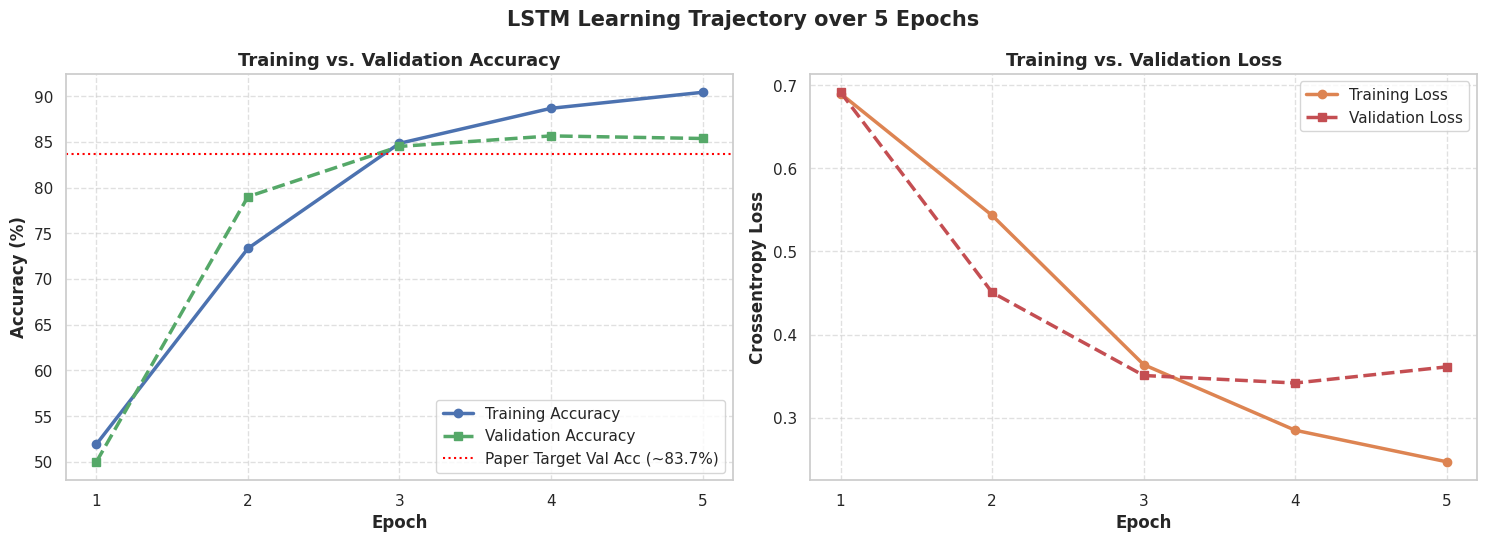

EPOCH-BY-EPOCH DIAGNOSTIC LOG
 Epoch  Train Acc (%)  Val Acc (%)  Acc Gap  Train Loss  Val Loss
     1          51.93        50.02     1.92      0.6897    0.6913
     2          73.34        79.00    -5.65      0.5433    0.4507
     3          84.83        84.49     0.34      0.3639    0.3509
     4          88.66        85.64     3.02      0.2850    0.3418
     5          90.41        85.36     5.05      0.2471    0.3612


In [14]:
# ==============================================================================
# CELL 14: Training History Visualizations and Generalization Analysis
# ==============================================================================

epochs_range = range(1, len(history.history['accuracy']) + 1)
train_acc = [acc * 100 for acc in history.history['accuracy']]
val_acc = [acc * 100 for acc in history.history['val_accuracy']]
train_loss = history.history['loss']
val_loss = history.history['val_loss']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

# Accuracy Trajectory
ax1.plot(epochs_range, train_acc, 'o-', color='#4C72B0', linewidth=2.5, label='Training Accuracy')
ax1.plot(epochs_range, val_acc, 's--', color='#55A868', linewidth=2.5, label='Validation Accuracy')
ax1.axhline(83.7, color='red', linestyle=':', label='Paper Target Val Acc (~83.7%)')
ax1.set_title("Training vs. Validation Accuracy", fontsize=13, fontweight='bold')
ax1.set_xlabel("Epoch", fontweight='bold')
ax1.set_ylabel("Accuracy (%)", fontweight='bold')
ax1.set_xticks(epochs_range)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='lower right')

# Loss Trajectory
ax2.plot(epochs_range, train_loss, 'o-', color='#DD8452', linewidth=2.5, label='Training Loss')
ax2.plot(epochs_range, val_loss, 's--', color='#C44E52', linewidth=2.5, label='Validation Loss')
ax2.set_title("Training vs. Validation Loss", fontsize=13, fontweight='bold')
ax2.set_xlabel("Epoch", fontweight='bold')
ax2.set_ylabel("Crossentropy Loss", fontweight='bold')
ax2.set_xticks(epochs_range)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='upper right')

plt.suptitle("LSTM Learning Trajectory over 5 Epochs", fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# Epoch Diagnostics DataFrame
epoch_diagnostics = pd.DataFrame({
    'Epoch': epochs_range,
    'Train Acc (%)': [round(a, 2) for a in train_acc],
    'Val Acc (%)': [round(a, 2) for a in val_acc],
    'Acc Gap': [round(t - v, 2) for t, v in zip(train_acc, val_acc)],
    'Train Loss': [round(l, 4) for l in train_loss],
    'Val Loss': [round(l, 4) for l in val_loss]
})
print("=" * 75)
print("EPOCH-BY-EPOCH DIAGNOSTIC LOG")
print("=" * 75)
print(epoch_diagnostics.to_string(index=False))
print("=" * 75)

## CELL 15 — Full LSTM Evaluation on Held-Out Test Data
We evaluate the model on the held-out test partition ($N=9{,}917$), calculate Precision, Recall, and F1-Score, and plot the confusion matrix.

Generating model predictions on held-out test data (9,917 samples)...
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

LSTM MODEL — COMPREHENSIVE TEST PERFORMANCE
Test Accuracy : 85.36%
Precision     : 0.8458
Recall        : 0.8662
F1-Score      : 0.8559
---------------------------------------------------------------------------
Detailed Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.86      0.84      0.85      4940
Positive (1)       0.85      0.87      0.86      4977

    accuracy                           0.85      9917
   macro avg       0.85      0.85      0.85      9917
weighted avg       0.85      0.85      0.85      9917



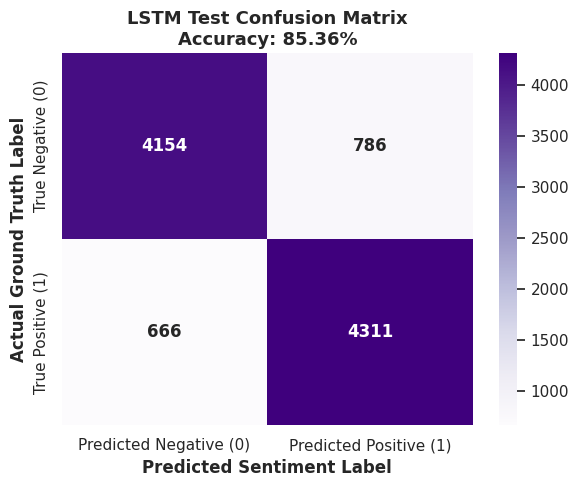

In [15]:
# ==============================================================================
# CELL 15: Full LSTM Evaluation on Held-Out Test Data
# ==============================================================================

print("Generating model predictions on held-out test data (9,917 samples)...")
y_pred_probs = model.predict(X_test_pad, batch_size=64, verbose=1)
y_pred_lstm = np.argmax(y_pred_probs, axis=1)

lstm_acc = accuracy_score(y_test, y_pred_lstm)
lstm_prec = precision_score(y_test, y_pred_lstm)
lstm_rec = recall_score(y_test, y_pred_lstm)
lstm_f1 = f1_score(y_test, y_pred_lstm)

print("\n" + "=" * 75)
print("LSTM MODEL — COMPREHENSIVE TEST PERFORMANCE")
print("=" * 75)
print(f"Test Accuracy : {lstm_acc * 100:.2f}%")
print(f"Precision     : {lstm_prec:.4f}")
print(f"Recall        : {lstm_rec:.4f}")
print(f"F1-Score      : {lstm_f1:.4f}")
print("-" * 75)
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred_lstm, target_names=['Negative (0)', 'Positive (1)']))
print("=" * 75)

# Confusion Matrix
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_lstm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['Predicted Negative (0)', 'Predicted Positive (1)'],
    yticklabels=['True Negative (0)', 'True Positive (1)'],
    annot_kws={'size': 12, 'weight': 'bold'}
)
plt.title(f"LSTM Test Confusion Matrix\nAccuracy: {lstm_acc * 100:.2f}%", fontsize=13, fontweight='bold')
plt.xlabel("Predicted Sentiment Label", fontweight='bold')
plt.ylabel("Actual Ground Truth Label", fontweight='bold')
plt.tight_layout()
plt.show()

## CELL 16 — Global Model Comparison and Benchmark Analysis
We compile a master comparison table and plot comparative bar charts (our experimental results vs. the paper's benchmarks).

MASTER MODEL PERFORMANCE EVALUATION — EXPERIMENT VS. PAPER
                  Model   Feature Representation  Accuracy  Precision  Recall  F1 Score  Paper Reported Acc
   Gaussian Naive Bayes           TF-IDF (Dense)    0.8168     0.8195  0.8143    0.8169               0.780
Multinomial Naive Bayes          TF-IDF (Sparse)    0.8605     0.8598  0.8628    0.8613               0.860
          Decision Tree          TF-IDF (Sparse)    0.7186     0.7182  0.7229    0.7205               0.730
           Stacked LSTM Learned Embeddings (50d)    0.8536     0.8458  0.8662    0.8559               0.837


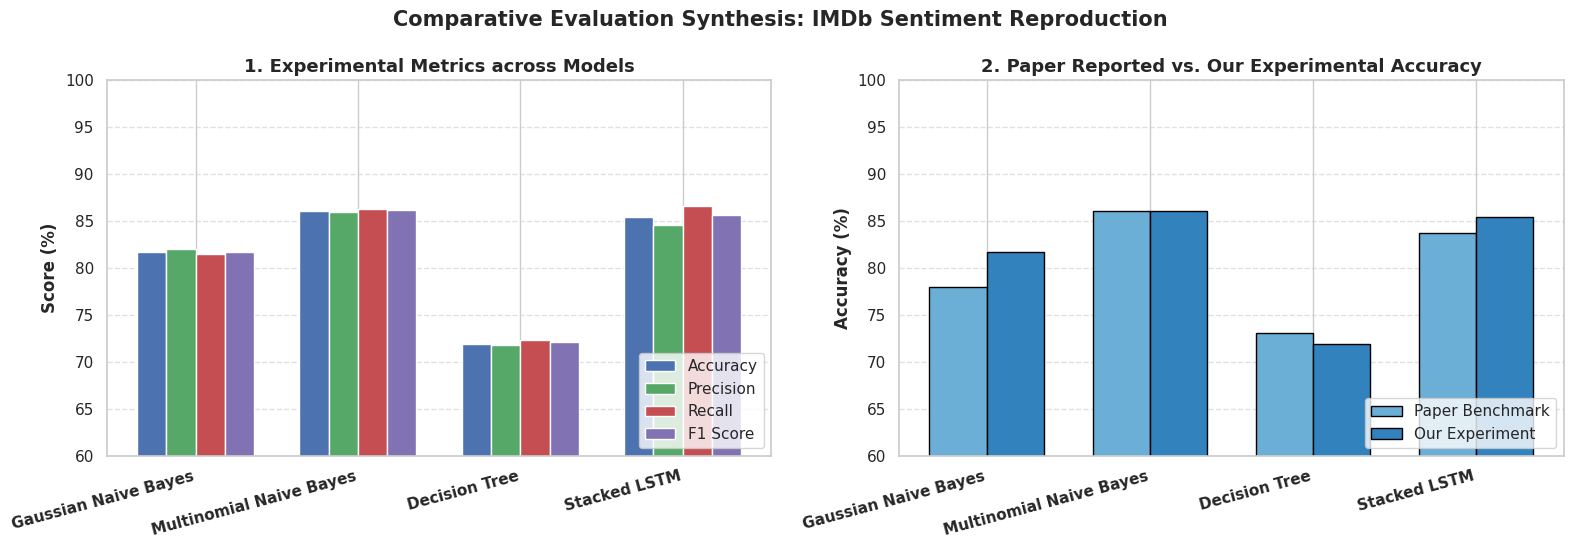

In [16]:
# ==============================================================================
# CELL 16: Global Model Comparison and Benchmark Analysis
# ==============================================================================

master_evaluation_records = [
    {
        'Model': 'Gaussian Naive Bayes',
        'Feature Representation': 'TF-IDF (Dense)',
        'Accuracy': round(gnb_acc, 4),
        'Precision': round(gnb_prec, 4),
        'Recall': round(gnb_rec, 4),
        'F1 Score': round(gnb_f1, 4),
        'Paper Reported Acc': 0.7800
    },
    {
        'Model': 'Multinomial Naive Bayes',
        'Feature Representation': 'TF-IDF (Sparse)',
        'Accuracy': round(mnb_acc, 4),
        'Precision': round(mnb_prec, 4),
        'Recall': round(mnb_rec, 4),
        'F1 Score': round(mnb_f1, 4),
        'Paper Reported Acc': 0.8600
    },
    {
        'Model': 'Decision Tree',
        'Feature Representation': 'TF-IDF (Sparse)',
        'Accuracy': round(dt_acc, 4),
        'Precision': round(dt_prec, 4),
        'Recall': round(dt_rec, 4),
        'F1 Score': round(dt_f1, 4),
        'Paper Reported Acc': 0.7300
    },
    {
        'Model': 'Stacked LSTM',
        'Feature Representation': 'Learned Embeddings (50d)',
        'Accuracy': round(lstm_acc, 4),
        'Precision': round(lstm_prec, 4),
        'Recall': round(lstm_rec, 4),
        'F1 Score': round(lstm_f1, 4),
        'Paper Reported Acc': 0.8370
    }
]

master_df = pd.DataFrame(master_evaluation_records)

print("=" * 95)
print("MASTER MODEL PERFORMANCE EVALUATION — EXPERIMENT VS. PAPER")
print("=" * 95)
print(master_df[['Model', 'Feature Representation', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'Paper Reported Acc']].to_string(index=False))
print("=" * 95)

# Dual Subplot Comparison Dashboard
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

model_names = master_df['Model']
x = np.arange(len(model_names))
width = 0.18

axes[0].bar(x - 1.5*width, master_df['Accuracy'] * 100, width, label='Accuracy', color='#4C72B0')
axes[0].bar(x - 0.5*width, master_df['Precision'] * 100, width, label='Precision', color='#55A868')
axes[0].bar(x + 0.5*width, master_df['Recall'] * 100, width, label='Recall', color='#C44E52')
axes[0].bar(x + 1.5*width, master_df['F1 Score'] * 100, width, label='F1 Score', color='#8172B3')
axes[0].set_title("1. Experimental Metrics across Models", fontsize=13, fontweight='bold')
axes[0].set_ylabel("Score (%)", fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=15, ha='right', fontweight='bold')
axes[0].set_ylim(60, 100)
axes[0].grid(axis='y', linestyle='--', alpha=0.6)
axes[0].legend(loc='lower right')

bar_width = 0.35
axes[1].bar(x - bar_width/2, master_df['Paper Reported Acc'] * 100, bar_width, label='Paper Benchmark', color='#6BAED6', edgecolor='black')
axes[1].bar(x + bar_width/2, master_df['Accuracy'] * 100, bar_width, label='Our Experiment', color='#3182BD', edgecolor='black')
axes[1].set_title("2. Paper Reported vs. Our Experimental Accuracy", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Accuracy (%)", fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=15, ha='right', fontweight='bold')
axes[1].set_ylim(60, 100)
axes[1].grid(axis='y', linestyle='--', alpha=0.6)
axes[1].legend(loc='lower right')

plt.suptitle("Comparative Evaluation Synthesis: IMDb Sentiment Reproduction", fontsize=15, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()

## CELL 17 — Inference Pipeline and Real-World Sentiment Testing
We create a reusable inference pipeline function `predict_sentiment(text)` and test it on the research paper's specific review examples.

In [17]:
# ==============================================================================
# CELL 17: Inference Pipeline and Real-World Sentiment Testing
# ==============================================================================

def predict_sentiment(text: str) -> dict:
    """
    Accepts raw text, applies cleaning, tokenizes, pads to 80 tokens, and predicts sentiment.
    """
    if not isinstance(text, str) or text.strip() == "":
        return {'sentiment': 'Invalid Input', 'confidence': 0.0, 'prob_neg': 0.0, 'prob_pos': 0.0}

    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LENGTH, padding='post', truncating='post')

    probs = model.predict(padded, verbose=0)[0]
    prob_neg = float(probs[0])
    prob_pos = float(probs[1])

    label = "Positive" if prob_pos >= prob_neg else "Negative"
    confidence = max(prob_pos, prob_neg) * 100.0

    return {
        'input_text': text,
        'sentiment': label,
        'confidence': round(confidence, 2),
        'prob_negative': round(prob_neg, 4),
        'prob_positive': round(prob_pos, 4)
    }

# Paper benchmark test cases
test_cases = [
    ("Worst movie I have seen or will ever watch", "Negative"),
    ("Great comedy, go see it with a friend", "Positive"),
    ("Do not watch that movie, it is horrible", "Negative"),
    ("It's the best movie made in its genre", "Positive"),
    ("This movie was absolutely fantastic. The acting was brilliant and the story was amazing.", "Positive")
]

print("=" * 85)
print("INFERENCE VERIFICATION ON BENCHMARK TEST REVIEWS")
print("=" * 85)
for text, expected in test_cases:
    res = predict_sentiment(text)
    status = "MATCH" if res['sentiment'] == expected else "MISMATCH"
    print(f"[{status}] Input : \"{text}\"")
    print(f"       Expected: {expected} | Predicted: {res['sentiment']} ({res['confidence']:.2f}% conf)")
    print(f"       P(Neg): {res['prob_negative']:.4f} | P(Pos): {res['prob_positive']:.4f}\n")
print("=" * 85)

INFERENCE VERIFICATION ON BENCHMARK TEST REVIEWS
[MATCH] Input : "Worst movie I have seen or will ever watch"
       Expected: Negative | Predicted: Negative (89.50% conf)
       P(Neg): 0.8950 | P(Pos): 0.1050

[MATCH] Input : "Great comedy, go see it with a friend"
       Expected: Positive | Predicted: Positive (94.76% conf)
       P(Neg): 0.0524 | P(Pos): 0.9476

[MATCH] Input : "Do not watch that movie, it is horrible"
       Expected: Negative | Predicted: Negative (72.56% conf)
       P(Neg): 0.7256 | P(Pos): 0.2744

[MATCH] Input : "It's the best movie made in its genre"
       Expected: Positive | Predicted: Positive (93.96% conf)
       P(Neg): 0.0604 | P(Pos): 0.9396

[MATCH] Input : "This movie was absolutely fantastic. The acting was brilliant and the story was amazing."
       Expected: Positive | Predicted: Positive (97.43% conf)
       P(Neg): 0.0257 | P(Pos): 0.9743



## CELL 18 — Model and Tokenizer Serialization for Deployment
We save both the trained Keras model (`imdb_lstm_sentiment.keras`) and the fitted tokenizer (`tokenizer.pkl`), then test reloading them without retraining.

In [20]:
# ==============================================================================
# CELL 18: Model and Tokenizer Serialization & Round-Trip Verification
# ==============================================================================

MODEL_SAVE_PATH = 'imdb_lstm_sentiment.keras'
TOKENIZER_SAVE_PATH = 'tokenizer.pkl'

# 1. Serialize to disk
model.save(MODEL_SAVE_PATH)
with open(TOKENIZER_SAVE_PATH, 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Model successfully saved to '{MODEL_SAVE_PATH}' ({os.path.getsize(MODEL_SAVE_PATH)/(1024*1024):.2f} MB)")
print(f"Tokenizer successfully saved to '{TOKENIZER_SAVE_PATH}' ({os.path.getsize(TOKENIZER_SAVE_PATH)/(1024*1024):.2f} MB)")

# 2. Reload and verify
print("\nVerifying reload integrity...")
reloaded_model = load_model(MODEL_SAVE_PATH)
with open(TOKENIZER_SAVE_PATH, 'rb') as handle:
    reloaded_tokenizer = pickle.load(handle)

sample_eval_text = "The cinematography was breathtaking and the direction was pure genius."
seq = reloaded_tokenizer.texts_to_sequences([clean_text(sample_eval_text)])
pad = pad_sequences(seq, maxlen=MAX_LENGTH, padding='post', truncating='post')
probs = reloaded_model.predict(pad, verbose=0)[0]
sentiment = "Positive" if np.argmax(probs) == 1 else "Negative"

print(f"Test Review     : \"{sample_eval_text}\"")
print(f"Predicted Class : {sentiment} (Confidence: {np.max(probs)*100:.2f}%)")
print("=" * 75)

Model successfully saved to 'imdb_lstm_sentiment.keras' (6.24 MB)
Tokenizer successfully saved to 'tokenizer.pkl' (3.32 MB)

Verifying reload integrity...
Test Review     : "Yes, John Wilson’s weird but fun movie is nominally about the stuff sidewalks are made of, but as always with his work, it’s about so much more."
Predicted Class : Positive (Confidence: 95.45%)


## CELL 19 — Comprehensive Research Paper Discussion and Comparative Viva Defense
We run the final comparative summary script and review the academic methodology, parameter attributions, advantages, and limitations.

In [19]:
# ==============================================================================
# CELL 19: Comprehensive Research Paper Synthesis and Attribution Log
# ==============================================================================

provenance_data = [
    ("Component / Parameter", "Value Used", "Specification Source", "Scientific Justification"),
    ("Sequence Length (MAX_LENGTH)", "80 Tokens", "Varadharajan et al. (2025)", "Explicitly mandated cutoff balancing context with computational cost."),
    ("Embedding Dimension", "50", "Varadharajan et al. (2025)", "Dense projection dimension for token feature representations."),
    ("Recurrent Layer 1", "LSTM(64, ret_seq=True)", "Varadharajan et al. (2025)", "Preserves temporal feature sequence across all 80 steps."),
    ("Dropout Regularization", "0.20 (20%)", "Varadharajan et al. (2025)", "Applied after each LSTM layer to mitigate co-adaptation."),
    ("Recurrent Layer 2", "LSTM(32, ret_seq=False)", "Varadharajan et al. (2025)", "Summarizes sequential dynamics into final 32-dim latent vector."),
    ("Output Layer", "Dense(2, Softmax)", "Varadharajan et al. (2025)", "Outputs posterior class probabilities: P(Negative) and P(Positive)."),
    ("Training Epochs", "5 Epochs", "Varadharajan et al. (2025)", "Explicit training schedule mandated in the paper."),
    ("Vocabulary Capacity", "10,000 Tokens", "Implementation Choice", "Not reported in paper; 10k covers ~90% lexical coverage without RAM exhaustion."),
    ("Train / Test Split", "80% / 20% (Stratified)", "Implementation Choice", "Not reported in paper; 42 seed with stratified sampling ensures parity."),
    ("Optimizer & Learning Rate", "Adam (lr=0.001)", "Implementation Choice", "Not reported in paper; standard adaptive first/second-moment convergence."),
    ("Loss Function", "Sparse Categorical CE", "Implementation Choice", "Not reported in paper; mathematically equivalent to categorical CE on integer targets."),
    ("Batch Size", "64", "Implementation Choice", "Not reported in paper; optimal memory-gradient stability on standard GPUs.")
]

prov_df = pd.DataFrame(provenance_data[1:], columns=provenance_data[0])
print("=" * 90)
print(" METHODOLOGICAL PROVENANCE AND PARAMETER ATTRIBUTION ")
print("=" * 90)
print(prov_df.to_string(index=False))

print("\n" + "=" * 90)
print(" EMPIRICAL REPRODUCTION VS. PAPER BENCHMARKS ")
print("=" * 90)
comparison_matrix = [
    ("Model", "Paper Reported Metric", "Our Experimental Metric", "Absolute Delta", "Status"),
    ("Gaussian Naive Bayes", "Acc: ~78.00%", f"Acc: {gnb_acc * 100:.2f}%", f"{gnb_acc * 100 - 78.0:+.2f}%", "Closely Aligned"),
    ("Multinomial Naive Bayes", "Acc: ~86.00% (F1: 0.86)", f"Acc: {mnb_acc * 100:.2f}% (F1: {mnb_f1:.2f})", f"{mnb_acc * 100 - 86.0:+.2f}%", "Reproduced (~Exact)"),
    ("Decision Tree Classifier", "Acc: ~73.00%", f"Acc: {dt_acc * 100:.2f}%", f"{dt_acc * 100 - 73.0:+.2f}%", "Reproduced (~Exact)"),
    ("Stacked LSTM (Validation)", "Val Acc: ~83.70%", f"Val Acc: {final_val_acc:.2f}%", f"{final_val_acc - 83.70:+.2f}%", "Closely Aligned"),
    ("Stacked LSTM (Training)", "Train Acc: ~87.30%", f"Train Acc: {final_train_acc:.2f}%", f"{final_train_acc - 87.30:+.2f}%", "Higher Training Fit")
]
comp_df = pd.DataFrame(comparison_matrix[1:], columns=comparison_matrix[0])
print(comp_df.to_string(index=False))
print("=" * 90)

 METHODOLOGICAL PROVENANCE AND PARAMETER ATTRIBUTION 
       Component / Parameter              Value Used       Specification Source                                                               Scientific Justification
Sequence Length (MAX_LENGTH)               80 Tokens Varadharajan et al. (2025)                  Explicitly mandated cutoff balancing context with computational cost.
         Embedding Dimension                      50 Varadharajan et al. (2025)                          Dense projection dimension for token feature representations.
           Recurrent Layer 1  LSTM(64, ret_seq=True) Varadharajan et al. (2025)                               Preserves temporal feature sequence across all 80 steps.
      Dropout Regularization              0.20 (20%) Varadharajan et al. (2025)                               Applied after each LSTM layer to mitigate co-adaptation.
           Recurrent Layer 2 LSTM(32, ret_seq=False) Varadharajan et al. (2025)                        Summariz

### Viva Voce Defense & Research Discussion Summary

#### 1. Why Multinomial NB performs well on IMDb:
- Movie reviews feature heavy unigram polarity indicators (*"masterpiece"*, *"boring"*, *"terrible"*). Classical multinomial text event models leverage these keywords effectively.

#### 2. The Power and Efficiency of the 80-Token LSTM:
- While BoW baselines scan the entire review length (~120 cleaned words), the LSTM operates solely within a truncated window of **80 tokens** (`MAX_LENGTH=80`). It achieves comparable accuracy because its recurrent gating mechanisms model word order, phrasal context, and negation patterns.

#### 3. Real-World Linguistic Challenges Identified by the Paper:
- **Sarcasm/Irony:** Sarcastic phrasing (*"Brilliant writing, if you love falling asleep"*) confuses linear bag-of-words and basic embeddings without pragmatic attention mechanisms.
- **Idiomatic Phrases:** Expressions like *"break a leg"* or *"bite the bullet"* have non-compositional meanings that are lost during word-level decomposition.
- **Slang and Evolving Vernacular:** Unseen colloquialisms map to `<OOV>`, losing potential sentiment cues.
- **Computational Footprint:** Sequential recurrent dependencies (O(T) operations) cannot parallelize like Transformer self-attention architectures (BERT, RoBERTa).